In [ ]:


import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise import accuracy
from surprise.model_selection import train_test_split

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current working directory:
c:\Users\LENOVO\Desktop\movielens\notebooks

Files and folders:
['Phase_1_Data_Collection.ipynb', 'Phase_2_Preprocessing_EDA.ipynb', 'Phase_6_Evaluation.ipynb']


In [ ]:




current_directory = os.getcwd()

if os.path.basename(current_directory).lower() == "notebooks":
    project_root = os.path.dirname(current_directory)
else:
    project_root = current_directory

print("Project root:")
print(project_root)

data_folder = os.path.join(
    project_root,
    "data"
)

movies_path = os.path.join(
    data_folder,
    "movies.csv"
)

ratings_path = os.path.join(
    data_folder,
    "ratings.csv"
)

print("\nMovies path:")
print(movies_path)

print("\nRatings path:")
print(ratings_path)

Project root:
c:\Users\LENOVO\Desktop\movielens

Movies path:
c:\Users\LENOVO\Desktop\movielens\data\movies.csv

Ratings path:
c:\Users\LENOVO\Desktop\movielens\data\ratings.csv


In [ ]:


if not os.path.exists(movies_path):
    raise FileNotFoundError(
        f"movies.csv not found at: {movies_path}"
    )

if not os.path.exists(ratings_path):
    raise FileNotFoundError(
        f"ratings.csv not found at: {ratings_path}"
    )

print("movies.csv found.")
print("ratings.csv found.")

movies.csv found.
ratings.csv found.


## 1. Load Dataset

The MovieLens dataset contains:

- Movie information
- User ratings
- User IDs
- Movie IDs
- Rating values

load data 

In [ ]:

movies = pd.read_csv(
    movies_path
)

ratings = pd.read_csv(
    ratings_path
)

print("Movies dataset shape:")
print(movies.shape)

print("\nRatings dataset shape:")
print(ratings.shape)

Movies dataset shape:
(10329, 3)

Ratings dataset shape:
(105339, 4)


 BASIC DATA INFORMATION

In [7]:


print("=" * 60)
print("MOVIE DATASET")
print("=" * 60)

display(movies.head())

print("\nColumns:")
print(movies.columns.tolist())

print("\nNumber of movies:")
print(movies["movieId"].nunique())


print("\n")
print("=" * 60)
print("RATINGS DATASET")
print("=" * 60)

display(ratings.head())

print("\nColumns:")
print(ratings.columns.tolist())

print("\nNumber of users:")
print(ratings["userId"].nunique())

print("\nNumber of ratings:")
print(len(ratings))

MOVIE DATASET


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Columns:
['movieId', 'title', 'genres']

Number of movies:
10329


RATINGS DATASET


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523



Columns:
['userId', 'movieId', 'rating', 'timestamp']

Number of users:
668

Number of ratings:
105339


2. Data Preparation

Only the columns required for recommendation evaluation are used.

The rating scale is obtained directly from the dataset instead of assuming a fixed scale.

prepare data 

In [8]:


movies = movies[
    [
        "movieId",
        "title",
        "genres"
    ]
].copy()

ratings = ratings[
    [
        "userId",
        "movieId",
        "rating"
    ]
].copy()

# Handle missing values
movies["title"] = (
    movies["title"]
    .fillna("Unknown Movie")
)

movies["genres"] = (
    movies["genres"]
    .fillna("Unknown")
)

ratings.dropna(
    subset=[
        "userId",
        "movieId",
        "rating"
    ],
    inplace=True
)

# Remove duplicate rows
movies.drop_duplicates(
    subset=["movieId"],
    inplace=True
)

ratings.drop_duplicates(
    inplace=True
)

# Correct data types
movies["movieId"] = (
    movies["movieId"]
    .astype(int)
)

ratings["userId"] = (
    ratings["userId"]
    .astype(int)
)

ratings["movieId"] = (
    ratings["movieId"]
    .astype(int)
)

ratings["rating"] = (
    ratings["rating"]
    .astype(float)
)

movies.reset_index(
    drop=True,
    inplace=True
)

ratings.reset_index(
    drop=True,
    inplace=True
)

print("Data preparation completed.")

print("\nMovies:", len(movies))
print("Users:", ratings["userId"].nunique())
print("Ratings:", len(ratings))

print(
    "\nRating scale:",
    ratings["rating"].min(),
    "to",
    ratings["rating"].max()
)

Data preparation completed.

Movies: 10329
Users: 668
Ratings: 105339

Rating scale: 0.5 to 5.0


3. Train-Test Split

The ratings dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to build the collaborative filtering model.

The testing data is used to evaluate the model on ratings that were not used during training.

create surpise dataset

In [9]:

min_rating = ratings["rating"].min()
max_rating = ratings["rating"].max()

reader = Reader(
    rating_scale=(
        min_rating,
        max_rating
    )
)

surprise_data = Dataset.load_from_df(
    ratings[
        [
            "userId",
            "movieId",
            "rating"
        ]
    ],
    reader
)

print("Surprise dataset created.")

Surprise dataset created.


TRAIN TEST SPLIT

In [10]:


trainset, testset = train_test_split(
    surprise_data,
    test_size=0.20,
    random_state=42
)

print("Training ratings:")
print(trainset.n_ratings)

print("\nTesting ratings:")
print(len(testset))

Training ratings:
84271

Testing ratings:
21068


4. Collaborative Filtering using SVD

Singular Value Decomposition (SVD) is used to learn latent relationships between users and movies.

The model learns:

- User preferences
- Movie characteristics
- User-movie interaction patterns

It then predicts ratings for unseen user-movie combinations.

TRAIN SVD MODEL

In [11]:


svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

print("Training SVD model...")

svd_model.fit(
    trainset
)

print("SVD model trained successfully.")

Training SVD model...
SVD model trained successfully.


Collaborative Filtering Error Metrics

RMSE

Root Mean Squared Error measures the average magnitude of prediction errors.

Lower RMSE indicates better prediction accuracy.

MAE

Mean Absolute Error measures the average absolute difference between actual and predicted ratings.

Lower MAE indicates better prediction accuracy.

CALCULATE RMSE AND MAE

In [12]:

predictions = svd_model.test(
    testset
)

print("=" * 60)
print("COLLABORATIVE FILTERING EVALUATION")
print("=" * 60)

rmse = accuracy.rmse(
    predictions,
    verbose=True
)

mae = accuracy.mae(
    predictions,
    verbose=True
)

print("\nFinal Metrics")
print("-" * 40)

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"MAE : {mae:.4f}"
)

COLLABORATIVE FILTERING EVALUATION
RMSE: 0.8671
MAE:  0.6719

Final Metrics
----------------------------------------
RMSE: 0.8671
MAE : 0.6719


Prepare Training and Testing DataFrames

In [13]:
#  CONVERT TRAINING DATA

train_pairs = []

for inner_user_id in trainset.all_users():

    raw_user_id = trainset.to_raw_uid(
        inner_user_id
    )

    for inner_item_id, rating_value in trainset.ur[
        inner_user_id
    ]:

        raw_movie_id = trainset.to_raw_iid(
            inner_item_id
        )

        train_pairs.append(
            [
                int(raw_user_id),
                int(raw_movie_id),
                float(rating_value)
            ]
        )

train_ratings = pd.DataFrame(
    train_pairs,
    columns=[
        "userId",
        "movieId",
        "rating"
    ]
)

print(
    "Training DataFrame shape:",
    train_ratings.shape
)

display(
    train_ratings.head()
)

Training DataFrame shape: (84271, 3)


,userId,movieId,rating
0,285,2605,3.0
1,285,3176,4.0
2,285,3285,3.0
3,285,2881,4.0
4,285,2722,3.0


CONVERT TEST DATA

In [14]:


test_ratings = pd.DataFrame(
    testset,
    columns=[
        "userId",
        "movieId",
        "rating"
    ]
)

test_ratings["userId"] = (
    test_ratings["userId"]
    .astype(int)
)

test_ratings["movieId"] = (
    test_ratings["movieId"]
    .astype(int)
)

test_ratings["rating"] = (
    test_ratings["rating"]
    .astype(float)
)

print(
    "Testing DataFrame shape:",
    test_ratings.shape
)

display(
    test_ratings.head()
)

Testing DataFrame shape: (21068, 3)


,userId,movieId,rating
0,33,1207,5.0
1,420,597,5.0
2,432,1377,5.0
3,160,1209,3.0
4,281,1036,4.0


 7. Content-Based Filtering

The content-based recommender uses movie genres.

The process is:

Genres → TF-IDF → Cosine Similarity → Recommendations

TF-IDF converts genre information into numerical vectors.

Cosine similarity measures similarity between movie profiles.

In [15]:

# BUILD CONTENT MODEL


genre_text = (
    movies["genres"]
    .str.replace(
        "|",
        " ",
        regex=False
    )
)

vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(
    genre_text
)

movie_id_to_index = pd.Series(
    movies.index,
    index=movies["movieId"]
)

print(
    "TF-IDF matrix shape:",
    tfidf_matrix.shape
)

print(
    "Content-based model created successfully."
)

TF-IDF matrix shape: (10329, 23)
Content-based model created successfully.


In [16]:

#  HELPER FUNCTIONS


def get_train_rated_movies(user_id):

    user_data = train_ratings[
        train_ratings["userId"] == user_id
    ]

    return set(
        user_data["movieId"].tolist()
    )


def get_test_relevant_movies(
    user_id,
    threshold=4.0
):

    user_data = test_ratings[
        test_ratings["userId"] == user_id
    ]

    relevant = user_data[
        user_data["rating"] >= threshold
    ]

    return set(
        relevant["movieId"].tolist()
    )


def normalize_scores(scores):

    scores = np.asarray(
        scores,
        dtype=float
    )

    if len(scores) == 0:
        return scores

    minimum = scores.min()
    maximum = scores.max()

    if maximum == minimum:
        return np.zeros(
            len(scores)
        )

    return (
        scores - minimum
    ) / (
        maximum - minimum
    )

In [17]:

# COLLABORATIVE RECOMMENDATION


def collaborative_recommend(
    user_id,
    k=10
):

    rated_movies = (
        get_train_rated_movies(
            user_id
        )
    )

    candidates = movies[
        ~movies["movieId"].isin(
            rated_movies
        )
    ].copy()

    predicted_scores = []

    for movie_id in candidates[
        "movieId"
    ]:

        prediction = svd_model.predict(
            user_id,
            movie_id
        )

        predicted_scores.append(
            prediction.est
        )

    candidates["score"] = (
        predicted_scores
    )

    recommendations = (
        candidates
        .sort_values(
            "score",
            ascending=False
        )
        .head(k)
        .copy()
    )

    return recommendations

In [18]:

# CONTENT SCORE FUNCTION


def content_scores_for_user(
    user_id
):

    user_data = train_ratings[
        train_ratings["userId"] == user_id
    ]

    liked_movies = user_data[
        user_data["rating"] >= 4.0
    ]["movieId"].tolist()

    if len(liked_movies) == 0:

        return np.zeros(
            len(movies)
        )

    liked_indexes = []

    for movie_id in liked_movies:

        if movie_id in movie_id_to_index:

            liked_indexes.append(
                int(
                    movie_id_to_index[
                        movie_id
                    ]
                )
            )

    if len(liked_indexes) == 0:

        return np.zeros(
            len(movies)
        )

    similarity_matrix = linear_kernel(
        tfidf_matrix[
            liked_indexes
        ],
        tfidf_matrix
    )

    scores = similarity_matrix.max(
        axis=0
    )

    return np.asarray(
        scores
    )

In [19]:

# CELL 26 - CONTENT RECOMMENDATION


def content_recommend(
    user_id,
    k=10
):

    rated_movies = (
        get_train_rated_movies(
            user_id
        )
    )

    scores = (
        content_scores_for_user(
            user_id
        )
    )

    candidates = movies.copy()

    candidates["score"] = (
        scores
    )

    candidates = candidates[
        ~candidates["movieId"].isin(
            rated_movies
        )
    ]

    recommendations = (
        candidates
        .sort_values(
            "score",
            ascending=False
        )
        .head(k)
        .copy()
    )

    return recommendations

11. Hybrid Recommendation

The hybrid system combines:

- Content-Based score
- Collaborative Filtering score

The final score is calculated as:

Hybrid Score =

0.4 × Content Score

+

0.6 × Collaborative Score

The collaborative component receives a slightly higher weight because it directly uses user-rating behavior.

In [20]:

# HYBRID RECOMMENDATION


def hybrid_recommend(
    user_id,
    k=10,
    content_weight=0.4,
    collaborative_weight=0.6
):

    rated_movies = (
        get_train_rated_movies(
            user_id
        )
    )

    candidates = movies[
        ~movies["movieId"].isin(
            rated_movies
        )
    ].copy()

    # --------------------------------------------------------
    # Content scores
    # --------------------------------------------------------

    all_content_scores = (
        content_scores_for_user(
            user_id
        )
    )

    content_scores = []

    for movie_id in candidates[
        "movieId"
    ]:

        movie_index = (
            movie_id_to_index[
                movie_id
            ]
        )

        content_scores.append(
            all_content_scores[
                int(movie_index)
            ]
        )

    content_scores = np.asarray(
        content_scores
    )

    # --------------------------------------------------------
    # Collaborative scores
    # --------------------------------------------------------

    collaborative_scores = []

    for movie_id in candidates[
        "movieId"
    ]:

        prediction = svd_model.predict(
            user_id,
            movie_id
        )

        collaborative_scores.append(
            prediction.est
        )

    collaborative_scores = np.asarray(
        collaborative_scores
    )

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    normalized_content = (
        normalize_scores(
            content_scores
        )
    )

    normalized_collaborative = (
        normalize_scores(
            collaborative_scores
        )
    )

    # --------------------------------------------------------
    # Hybrid score
    # --------------------------------------------------------

    hybrid_scores = (
        content_weight
        * normalized_content
        +
        collaborative_weight
        * normalized_collaborative
    )

    candidates["score"] = (
        hybrid_scores
    )

    recommendations = (
        candidates
        .sort_values(
            "score",
            ascending=False
        )
        .head(k)
        .copy()
    )

    return recommendations

In [21]:

# TEST RECOMMENDATIONS


test_user = int(
    test_ratings["userId"].iloc[0]
)

print(
    "Testing user:",
    test_user
)


print("\n")
print("=" * 60)
print("COLLABORATIVE RECOMMENDATIONS")
print("=" * 60)

display(
    collaborative_recommend(
        test_user,
        k=10
    )
)


print("\n")
print("=" * 60)
print("CONTENT-BASED RECOMMENDATIONS")
print("=" * 60)

display(
    content_recommend(
        test_user,
        k=10
    )
)


print("\n")
print("=" * 60)
print("HYBRID RECOMMENDATIONS")
print("=" * 60)

display(
    hybrid_recommend(
        test_user,
        k=10
    )
)

Testing user: 33


COLLABORATIVE RECOMMENDATIONS


,movieId,title,genres,score
656,800,Lone Star (1996),Drama|Mystery|Western,4.929090
958,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,4.890329
4278,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,4.882660
744,923,Citizen Kane (1941),Drama|Mystery,4.880766
2398,3000,Princess Mononoke (Mononoke-hime) (1997),Action|Adventure|Animation|Drama|Fantasy,4.874506
922,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,4.863177
484,541,Blade Runner (1982),Action|Sci-Fi|Thriller,4.828891
938,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.806358
28,29,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,4.802737
3329,4235,Amores Perros (Love's a Bitch) (2000),Drama|Thriller,4.750869




CONTENT-BASED RECOMMENDATIONS


,movieId,title,genres,score
519,586,Home Alone (1990),Children|Comedy,1.0
834,1027,Robin Hood: Prince of Thieves (1991),Adventure|Drama,1.0
9154,90403,"Three Musketeers, The (2011)",Action|Adventure,1.0
4957,6794,Beethoven's 2nd (1993),Children|Comedy,1.0
9583,100091,Hitler's Madman (1943),Drama|War,1.0
186,214,Before the Rain (Pred dozhdot) (1994),Drama|War,1.0
597,704,"Quest, The (1996)",Action|Adventure,1.0
4937,6760,In This World (2002),Adventure|Drama,1.0
5894,8978,Christmas with the Kranks (2004),Children|Comedy,1.0
943,1178,Paths of Glory (1957),Drama|War,1.0




HYBRID RECOMMENDATIONS


,movieId,title,genres,score
744,923,Citizen Kane (1941),Drama|Mystery,0.989128
938,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,0.972387
3329,4235,Amores Perros (Love's a Bitch) (2000),Drama|Thriller,0.959903
1310,1641,"Full Monty, The (1997)",Comedy|Drama,0.947017
943,1178,Paths of Glory (1957),Drama|War,0.943369
279,318,"Shawshank Redemption, The (1994)",Crime|Drama,0.942507
9268,92259,Intouchables (2011),Comedy|Drama,0.941793
3108,3949,Requiem for a Dream (2000),Drama,0.938057
3887,4995,"Beautiful Mind, A (2001)",Drama|Romance,0.936827
982,1221,"Godfather: Part II, The (1974)",Crime|Drama,0.936463


13. Ranking Metrics

### Precision@10

Precision@10 measures how many of the recommended movies are relevant.

A movie is considered relevant when the user gave it a rating of 4.0 or higher in the test set.

### Recall@10

Recall@10 measures how many of the user's relevant movies were successfully recommended in the top 10 results.

Higher values indicate better recommendation quality.

In [22]:
# PRECISION AND RECALL FUNCTIONS


def precision_at_k(
    recommended_movies,
    relevant_movies,
    k=10
):

    recommended_movies = (
        recommended_movies[:k]
    )

    if len(recommended_movies) == 0:
        return 0.0

    hits = len(
        set(recommended_movies)
        .intersection(
            relevant_movies
        )
    )

    return (
        hits /
        len(recommended_movies)
    )


def recall_at_k(
    recommended_movies,
    relevant_movies,
    k=10
):

    if len(relevant_movies) == 0:
        return 0.0

    recommended_movies = (
        recommended_movies[:k]
    )

    hits = len(
        set(recommended_movies)
        .intersection(
            relevant_movies
        )
    )

    return (
        hits /
        len(relevant_movies)
    )

In [23]:
# PRECISION AND RECALL FUNCTIONS


def precision_at_k(
    recommended_movies,
    relevant_movies,
    k=10
):

    recommended_movies = (
        recommended_movies[:k]
    )

    if len(recommended_movies) == 0:
        return 0.0

    hits = len(
        set(recommended_movies)
        .intersection(
            relevant_movies
        )
    )

    return (
        hits /
        len(recommended_movies)
    )


def recall_at_k(
    recommended_movies,
    relevant_movies,
    k=10
):

    if len(relevant_movies) == 0:
        return 0.0

    recommended_movies = (
        recommended_movies[:k]
    )

    hits = len(
        set(recommended_movies)
        .intersection(
            relevant_movies
        )
    )

    return (
        hits /
        len(relevant_movies)
    )

In [25]:
# MODEL EVALUATION FUNCTION


def evaluate_model(
    model_name,
    k=10,
    max_users=100
):

    print("\n")
    print("=" * 60)
    print(
        f"EVALUATING {model_name.upper()}"
    )
    print("=" * 60)

    # --------------------------------------------------------
    # Find users with relevant test movies
    # --------------------------------------------------------

    eligible_users = []

    for user_id in test_ratings[
        "userId"
    ].unique():

        relevant_movies = (
            get_test_relevant_movies(
                user_id
            )
        )

        if len(relevant_movies) > 0:

            eligible_users.append(
                user_id
            )

    # --------------------------------------------------------
    # Limit users
    # --------------------------------------------------------

    if max_users is not None:

        eligible_users = (
            eligible_users[:max_users]
        )

    print(
        "Users selected:",
        len(eligible_users)
    )

    # --------------------------------------------------------
    # Metric storage
    # --------------------------------------------------------

    precision_values = []
    recall_values = []

    recommended_catalog = set()

    # --------------------------------------------------------
    # Evaluate each user
    # --------------------------------------------------------

    for counter, user_id in enumerate(
        eligible_users,
        start=1
    ):

        relevant_movies = (
            get_test_relevant_movies(
                user_id
            )
        )

        # ----------------------------------------------------
        # Recommendations
        # ----------------------------------------------------

        if model_name == "Collaborative":

            recommendations = (
                collaborative_recommend(
                    user_id,
                    k
                )
            )

        elif model_name == "Content-Based":

            recommendations = (
                content_recommend(
                    user_id,
                    k
                )
            )

        elif model_name == "Hybrid":

            recommendations = (
                hybrid_recommend(
                    user_id,
                    k
                )
            )

        else:

            raise ValueError(
                "Invalid model name."
            )

        # ----------------------------------------------------
        # Recommended movie IDs
        # ----------------------------------------------------

        recommended_ids = (
            recommendations[
                "movieId"
            ].tolist()
        )

        # ----------------------------------------------------
        # Precision
        # ----------------------------------------------------

        precision = (
            precision_at_k(
                recommended_ids,
                relevant_movies,
                k
            )
        )

        # ----------------------------------------------------
        # Recall
        # ----------------------------------------------------

        recall = (
            recall_at_k(
                recommended_ids,
                relevant_movies,
                k
            )
        )

        precision_values.append(
            precision
        )

        recall_values.append(
            recall
        )

        recommended_catalog.update(
            recommended_ids
        )

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if counter % 10 == 0:

            print(
                f"Evaluated {counter} users..."
            )

    # --------------------------------------------------------
    # Calculate averages
    # --------------------------------------------------------

    if len(precision_values) == 0:

        return {
            "Model": model_name,
            "Precision@10": 0.0,
            "Recall@10": 0.0,
            "Coverage": 0.0
        }

    precision_average = np.mean(
        precision_values
    )

    recall_average = np.mean(
        recall_values
    )

    coverage = (
        len(recommended_catalog)
        /
        len(movies)
    )

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print("\nResults")
    print("-" * 40)

    print(
        f"Precision@{k}: "
        f"{precision_average:.4f}"
    )

    print(
        f"Recall@{k}: "
        f"{recall_average:.4f}"
    )

    print(
        f"Coverage: "
        f"{coverage:.4f}"
    )

    return {
        "Model": model_name,
        f"Precision@{k}": precision_average,
        f"Recall@{k}": recall_average,
        "Coverage": coverage
    }

In [ ]:
15. Run Model Evaluation

For the first run, 100 users are evaluated to confirm that the complete evaluation pipeline works correctly.

After successful execution, the evaluation can be repeated using all eligible users.

In [26]:
# RUN EVALUATION


K = 10

MAX_USERS = 100

print(
    "Evaluation settings:"
)

print(
    f"K = {K}"
)

print(
    f"Maximum users = {MAX_USERS}"
)

Evaluation settings:
K = 10
Maximum users = 100


In [28]:

# CELL 35 - EVALUATE COLLABORATIVE


collaborative_results = evaluate_model(
    model_name="Collaborative",
    k=K,
    max_users=MAX_USERS
)

collaborative_results



EVALUATING COLLABORATIVE
Users selected: 100
Evaluated 10 users...
Evaluated 20 users...
Evaluated 30 users...
Evaluated 40 users...
Evaluated 50 users...
Evaluated 60 users...
Evaluated 70 users...
Evaluated 80 users...
Evaluated 90 users...
Evaluated 100 users...

Results
----------------------------------------
Precision@10: 0.0790
Recall@10: 0.0373
Coverage: 0.0209


{'Model': 'Collaborative',
 'Precision@10': np.float64(0.079),
 'Recall@10': np.float64(0.03730685887364962),
 'Coverage': 0.02091199535288992}

In [30]:
# EVALUATE HYBRID
hybrid_results = evaluate_model(
    model_name="Hybrid",
    k=K,
    max_users=MAX_USERS
)

hybrid_results



EVALUATING HYBRID
Users selected: 100
Evaluated 10 users...
Evaluated 20 users...
Evaluated 30 users...
Evaluated 40 users...
Evaluated 50 users...
Evaluated 60 users...
Evaluated 70 users...
Evaluated 80 users...
Evaluated 90 users...
Evaluated 100 users...

Results
----------------------------------------
Precision@10: 0.0970
Recall@10: 0.0367
Coverage: 0.0253


{'Model': 'Hybrid',
 'Precision@10': np.float64(0.09700000000000002),
 'Recall@10': np.float64(0.036660598339359717),
 'Coverage': 0.025268661051408656}

In [31]:
# CREATE FINAL RESULTS TABLE


collaborative_results["RMSE"] = rmse
collaborative_results["MAE"] = mae

content_results["RMSE"] = np.nan
content_results["MAE"] = np.nan

hybrid_results["RMSE"] = np.nan
hybrid_results["MAE"] = np.nan

evaluation_results = pd.DataFrame(
    [
        collaborative_results,
        content_results,
        hybrid_results
    ]
)

evaluation_results = evaluation_results[
    [
        "Model",
        "RMSE",
        "MAE",
        "Precision@10",
        "Recall@10",
        "Coverage"
    ]
]

print(
    "=" * 70
)

print(
    "FINAL MODEL COMPARISON"
)

print(
    "=" * 70
)

display(
    evaluation_results
)

FINAL MODEL COMPARISON


,Model,RMSE,MAE,Precision@10,Recall@10,Coverage
0,Collaborative,0.867122,0.671941,0.079,0.037307,0.020912
1,Content-Based,NaN,NaN,0.002,0.000188,0.052474
2,Hybrid,NaN,NaN,0.097,0.036661,0.025269


In [32]:
# ============================================================
# CELL 39 - SAVE RESULTS
# ============================================================

results_path = os.path.join(
    project_root,
    "evaluation_results.csv"
)

evaluation_results.to_csv(
    results_path,
    index=False
)

print(
    "Evaluation results saved successfully:"
)

print(
    results_path
)

Evaluation results saved successfully:
c:\Users\LENOVO\Desktop\movielens\evaluation_results.csv


In [33]:
# ============================================================
# CELL 40 - FIND BEST MODEL
# ============================================================

best_model_index = (
    evaluation_results[
        "Precision@10"
    ].idxmax()
)

best_model = (
    evaluation_results.loc[
        best_model_index,
        "Model"
    ]
)

best_precision = (
    evaluation_results.loc[
        best_model_index,
        "Precision@10"
    ]
)

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(
    "Best model:",
    best_model
)

print(
    f"Precision@10: "
    f"{best_precision:.4f}"
)

BEST MODEL
Best model: Hybrid
Precision@10: 0.0970


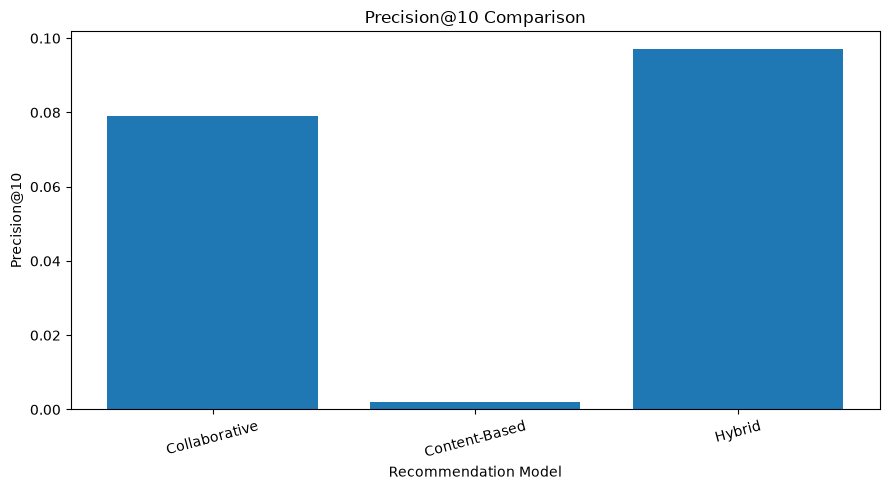

In [34]:
# ============================================================
# CELL 41 - PRECISION COMPARISON
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    evaluation_results["Model"],
    evaluation_results["Precision@10"]
)

plt.title(
    "Precision@10 Comparison"
)

plt.xlabel(
    "Recommendation Model"
)

plt.ylabel(
    "Precision@10"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

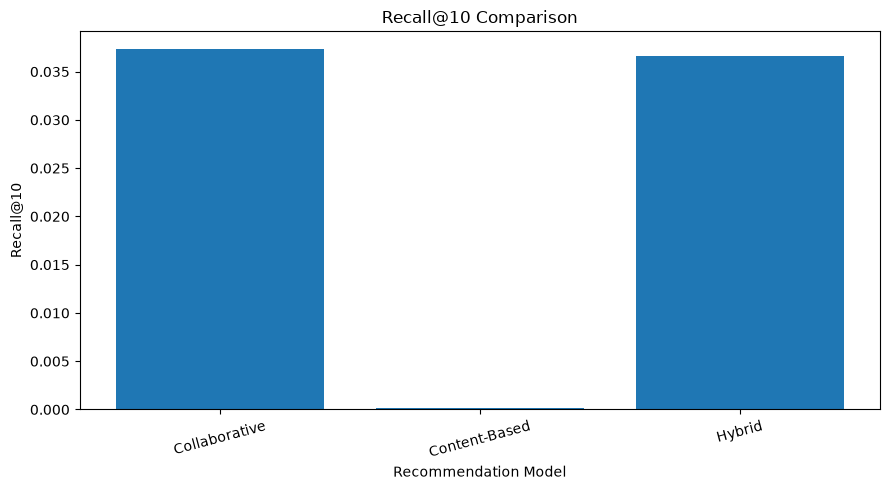

In [35]:
# ============================================================
# CELL 42 - RECALL COMPARISON
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    evaluation_results["Model"],
    evaluation_results["Recall@10"]
)

plt.title(
    "Recall@10 Comparison"
)

plt.xlabel(
    "Recommendation Model"
)

plt.ylabel(
    "Recall@10"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

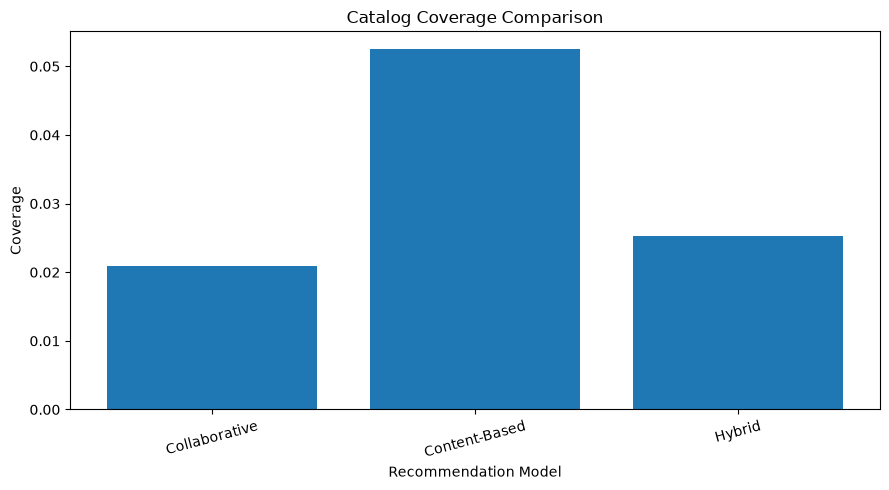

In [36]:
# ============================================================
# CELL 43 - COVERAGE COMPARISON
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    evaluation_results["Model"],
    evaluation_results["Coverage"]
)

plt.title(
    "Catalog Coverage Comparison"
)

plt.xlabel(
    "Recommendation Model"
)

plt.ylabel(
    "Coverage"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

In [37]:
# ============================================================
# CELL 44 - RMSE AND MAE
# ============================================================

print("=" * 60)
print("COLLABORATIVE FILTERING ACCURACY")
print("=" * 60)

print(
    f"RMSE = {rmse:.4f}"
)

print(
    f"MAE  = {mae:.4f}"
)

print("\nInterpretation:")

print(
    "Lower RMSE and MAE indicate better rating prediction accuracy."
)

COLLABORATIVE FILTERING ACCURACY
RMSE = 0.8671
MAE  = 0.6719

Interpretation:
Lower RMSE and MAE indicate better rating prediction accuracy.
